--- Steps 1 & 2: Loading Data ---
Data standardized successfully.


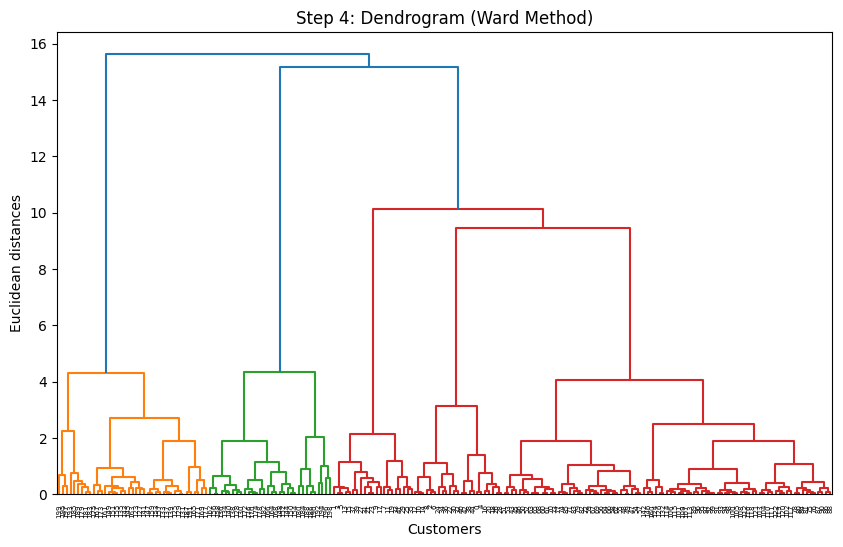

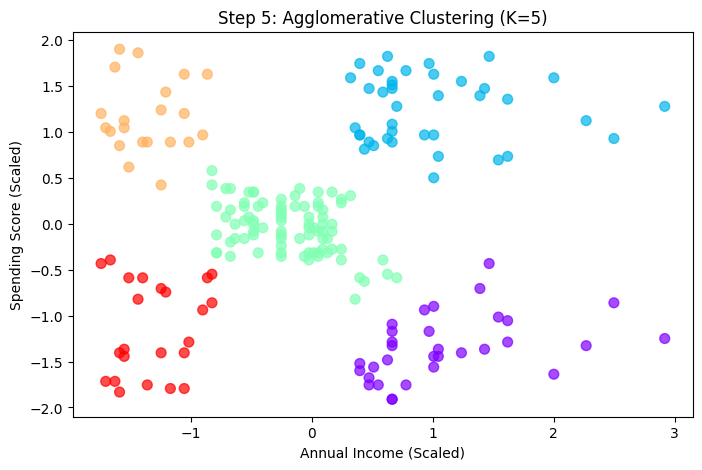

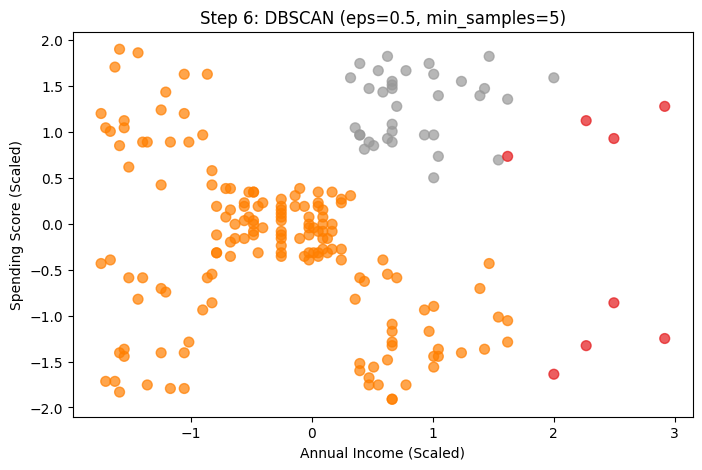


--- Step 7: Silhouette Scores ---
K-Means (K=5) Score:          0.5547
Agglomerative (K=5) Score:    0.5538
DBSCAN Score:                 0.3504

--- Step 8: Bonus (PCA with Age included) ---


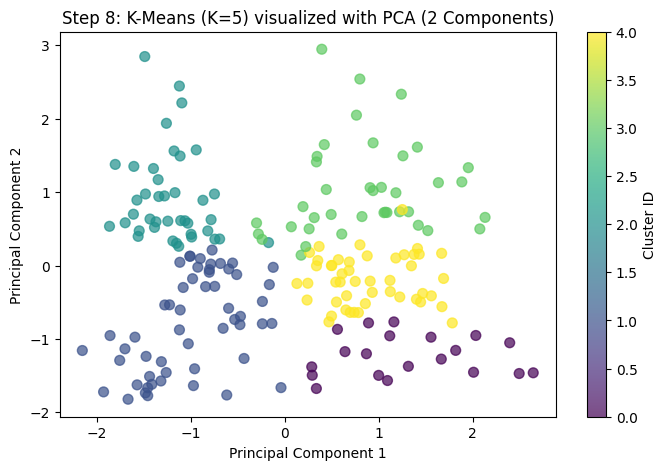

Explained Variance Ratio by the 2 Principal Components: 77.57%


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA

# ==========================================
# Steps 1 & 2: Load Data and Feature Matrix
# ==========================================
print("--- Steps 1 & 2: Loading Data ---")
df = pd.read_csv('Mall_Customers.csv')
df = df.rename(columns={
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
})

# Feature matrix X (Annual Income and Spending Score)
X = df[['AnnualIncome', 'SpendingScore']].values

# ==========================================
# Step 3: Standardize the Data
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data standardized successfully.")

# ==========================================
# Step 4: Hierarchical Clustering (Dendrogram)
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Step 4: Dendrogram (Ward Method)')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
# The ward method minimizes the variance within clusters
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.show()

# ==========================================
# Step 5: Agglomerative Clustering
# ==========================================
# Looking at the dendrogram, 5 is a solid choice for the number of clusters
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc = hc.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_hc, cmap='rainbow', s=50, alpha=0.7)
plt.title('Step 5: Agglomerative Clustering (K=5)')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.show()

# ==========================================
# Step 6: DBSCAN
# ==========================================
# DBSCAN finds core samples of high density and expands clusters from them
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
# Note: In DBSCAN, a label of -1 means the point is considered an outlier/noise
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_dbscan, cmap='Set1', s=50, alpha=0.7)
plt.title('Step 6: DBSCAN (eps=0.5, min_samples=5)')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.show()

# ==========================================
# Step 7: Model Evaluation (Silhouette Score)
# ==========================================
print("\n--- Step 7: Silhouette Scores ---")
# To compare fairly, we run K-Means on the scaled data as well
kmeans_scaled = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans_scaled = kmeans_scaled.fit_predict(X_scaled)

score_kmeans = silhouette_score(X_scaled, y_kmeans_scaled)
score_hc = silhouette_score(X_scaled, y_hc)
# We only calculate DBSCAN score if it found more than 1 cluster (excluding noise)
if len(set(y_dbscan)) > 1:
    score_dbscan = silhouette_score(X_scaled, y_dbscan)
else:
    score_dbscan = -1 # Indicates failure to find meaningful clusters

print(f"K-Means (K=5) Score:          {score_kmeans:.4f}")
print(f"Agglomerative (K=5) Score:    {score_hc:.4f}")
print(f"DBSCAN Score:                 {score_dbscan:.4f}")

# ==========================================
# Step 8: Bonus - PCA and 3 Variables
# ==========================================
print("\n--- Step 8: Bonus (PCA with Age included) ---")
# 1. Create new feature matrix with Age
X3 = df[['Age', 'AnnualIncome', 'SpendingScore']].values

# 2. Standardize
X3_scaled = scaler.fit_transform(X3)

# 3. Apply PCA to reduce from 3 dimensions down to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X3_scaled)

# 4. Train K-Means (K=5) on the 3D scaled data
kmeans_pca = KMeans(n_clusters=5, random_state=42, n_init=10)
y_pca_kmeans = kmeans_pca.fit_predict(X3_scaled)

# 5. Visualize the clusters on the 2D PCA plane
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pca_kmeans, cmap='viridis', s=50, alpha=0.7)
plt.title('Step 8: K-Means (K=5) visualized with PCA (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

print(f"Explained Variance Ratio by the 2 Principal Components: {pca.explained_variance_ratio_.sum() * 100:.2f}%")